In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("figures/Supplement_figures/Inference_no_drive", exist_ok=True)

import jax.numpy as jnp
import jax
import pickle
from scipy.stats import gamma
DATAPATH = "result/2_run_inference"

In [2]:


@jax.jit
def acf_jax(dataset, lags):
    data = jnp.asarray(dataset)
    t_len = data.shape[1]

    def acf_at_lag(lag):
        lag_abs = jnp.abs(lag)
        shifted = jnp.roll(data, shift=-lag, axis=1)
        valid = jnp.arange(t_len) < (t_len - lag_abs)
        valid = valid[None, :]
        return (
            jnp.nanmean(jnp.where(valid, data * shifted, jnp.nan))
            - jnp.nanmean(data) ** 2
        )

    return jax.vmap(acf_at_lag)(lags)


In [3]:
conditions = ["1.5kb", "340kb_Ce_Cp", "85kb", "170kb", "340kb_Ce", "255kb", "340kb_Cp", "340kb"]
condition_labels = ["1.5noC","339CECP","87noC","170noC","339CE","253noC","339CP","339noC"]

In [4]:
# grab parameters
loading_rates,loading_rates_std = [],[]
agg_loading_rates = []
kons,kons_CI,kons_std = [],[],[]
koff,koff_CI,koff_std = [],[],[]
predicted_MS2,observed_MS2 = [],[]
avg_observed_MS2 = []
lags_pon = np.arange(0, 400)
on_on_auto,off_off_auto = [],[]
test = []
pons = []
for condition in conditions:
    file_path = f"{DATAPATH}/{condition}/None/30s_{condition}_None_model_object.pkl"
    with open(file_path, "rb") as f:
        model_object = pickle.load(f)
        o_MS2 = model_object.M.get("MS2 Data")["data"]
        p_MS2 = np.where(~np.isnan(o_MS2),model_object.M.get("Polymerase Loadings")["Predicted MS2"],np.nan)
        lrs = model_object.M.get("Loading Rates")['Loading Rates <k>'].reshape(len(o_MS2),2)[:,0]
        (kon_shape,koff_shape),(kon_rate,koff_rate) = model_object.G["Transition Rates"].shape,model_object.G["Transition Rates"].rate
        predicted_MS2+=list(p_MS2.flatten())
        observed_MS2+=list(o_MS2.flatten())
        avg_observed_MS2.append(np.nanmean(o_MS2))
        agg_loading_rates.append(lrs.flatten())
        loading_rates.append(np.mean(lrs))
        not_prior = np.abs(0.6967116594314575-lrs)>0.05
        
        loading_rates_std.append(np.std(lrs[not_prior])/np.sqrt(np.sum(not_prior)))

        kons.append(kon_shape/kon_rate)
        koff.append(koff_shape/koff_rate)
        CI_kon = gamma.interval(0.95, kon_shape, scale=1/kon_rate)
        CI_koff = gamma.interval(0.95, koff_shape, scale=1/koff_rate)
        kons_std.append(gamma.std(kon_shape, scale=1/kon_rate))
        koff_std.append(gamma.std(koff_shape, scale=1/koff_rate))
        kons_CI.append(CI_kon)
        koff_CI.append(CI_koff)
        test.append(model_object.M.get("Transition Rates")["Transition Rates <k>"][0])
        pon = model_object.M.get("Promoter State")["masked_posterior"][1:,:,0].T
        on_on_auto.append(acf_jax(pon, lags_pon))
        off_off_auto.append(acf_jax(1-pon, lags_pon))
        pons.append(pon)
    

In [5]:

colors_pt = {
        "blue": "#0077BB",
        "magenta": "#EE3377",
        "teal": "#009988",
        "orange": "#EE7733",
        "cyan": "#33BBEE",
        "red": "#CC3311",
        "grey": "#BBBBBB",
    }

from matplotlib.colors import LinearSegmentedColormap


pt_heatmap_cmap = LinearSegmentedColormap.from_list(
    "PT_Inferno",
    [
        (0.00, "#000000"),
        (0.35, colors_pt["blue"]),
        (0.65, colors_pt["magenta"]),
        (0.85, colors_pt["orange"]),
        (1.00, "#FFDDAA"),
    ],
)


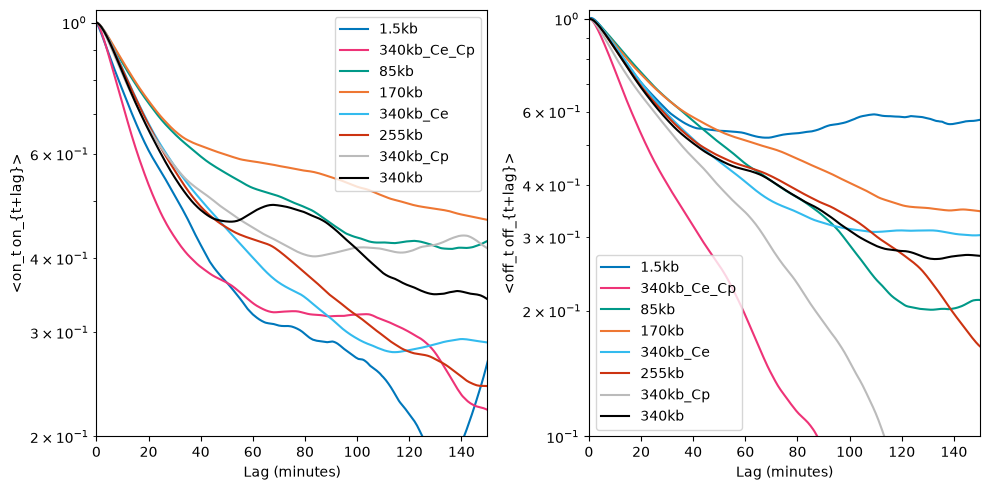

In [6]:
colors = list(colors_pt.values())+["black"]
frame_dt_min = 0.5

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for off_off, on_on, label in zip(off_off_auto, on_on_auto, conditions):
    ax[0].plot(lags_pon * frame_dt_min, off_off / off_off[0], label=label, color=colors[conditions.index(label)])
    ax[1].plot(lags_pon * frame_dt_min, on_on / on_on[0], label=label, color=colors[conditions.index(label)])
ax[0].set(
    xlabel="Lag (minutes)",
    ylabel="<on_t on_{t+lag}>",
    yscale="log",
    ylim=(0.2, 1.05),
    xlim=(0, 150),
)
ax[1].set(
    xlabel="Lag (minutes)",
    ylabel="<off_t off_{t+lag}>",
    yscale="log",
    ylim=(0.1, 1.05),
    xlim=(0, 150),
)
ax[0].legend()
ax[1].legend()
fig.tight_layout()
fig.savefig("figures/Supplement_figures/Inference_no_drive/burst_off_on.pdf")

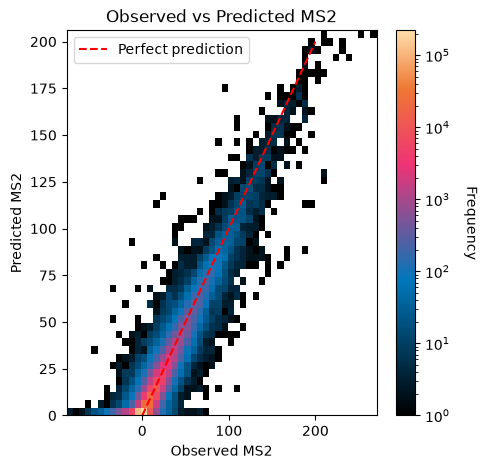

In [7]:
from matplotlib.colors import LogNorm
fig,ax = plt.subplots(1,1,figsize=(5,5))
# ax.scatter(observed_MS2,predicted_MS2,alpha=0.1,s=1)
arr_obs,arr_pred = np.array(observed_MS2),np.array(predicted_MS2)
nonan = ~np.isnan(arr_obs) & ~np.isnan(arr_pred)
arr_obs,arr_pred = arr_obs[nonan],arr_pred[nonan]
im = ax.hist2d(arr_obs,arr_pred,bins=50,norm=LogNorm(),cmap=pt_heatmap_cmap)
cbar = plt.colorbar(im[3], ax=ax)
cbar.set_label("Frequency",rotation=270,labelpad=20)
ax.plot([0, 200], [0, 200], 'r--',label="Perfect prediction")
ax.set(xlabel="Observed MS2", ylabel="Predicted MS2")
ax.legend()
ax.set_title("Observed vs Predicted MS2")
fig.savefig("figures/Supplement_figures/Inference_no_drive/Observed_vs_Predicted_MS2.pdf")

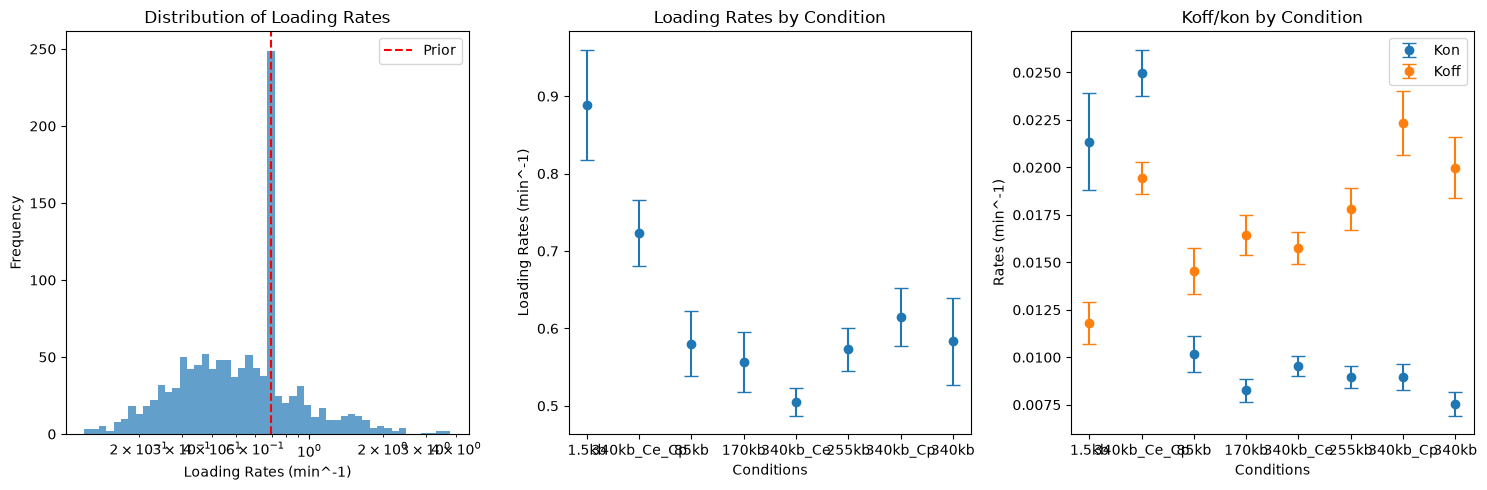

In [8]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
flattened_agg = np.concatenate(agg_loading_rates)
rmin,rmax = np.min(flattened_agg),np.max(flattened_agg)
nbins = 50
edges = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

ax[0].hist(flattened_agg,bins=edges,alpha=0.7)
ax[0].axvline(0.6967116594314575, color='red', linestyle='--',label="Prior")
ax[0].set(xlabel="Loading Rates (min^-1)", ylabel="Frequency", title="Distribution of Loading Rates", xscale="log")
ax[0].legend()
ax[1].errorbar(conditions,loading_rates,yerr=np.array(loading_rates_std).T,fmt='o',capsize=5)
ax[1].set(xlabel="Conditions", ylabel="Loading Rates (min^-1)", title="Loading Rates by Condition")

ax[2].errorbar(conditions,kons,yerr=kons_std,fmt='o',capsize=5,label="Kon")

ax[2].set(xlabel="Conditions", ylabel="Kon (min^-1)", title="Kon by Condition")

ax[2].errorbar(conditions,koff,yerr=koff_std,fmt='o',capsize=5,label="Koff")
ax[2].legend()
ax[2].set(xlabel="Conditions", ylabel="Rates (min^-1)", title="Koff/kon by Condition")
fig.tight_layout()
fig.savefig("figures/Supplement_figures/Inference_no_drive/Rates.pdf")


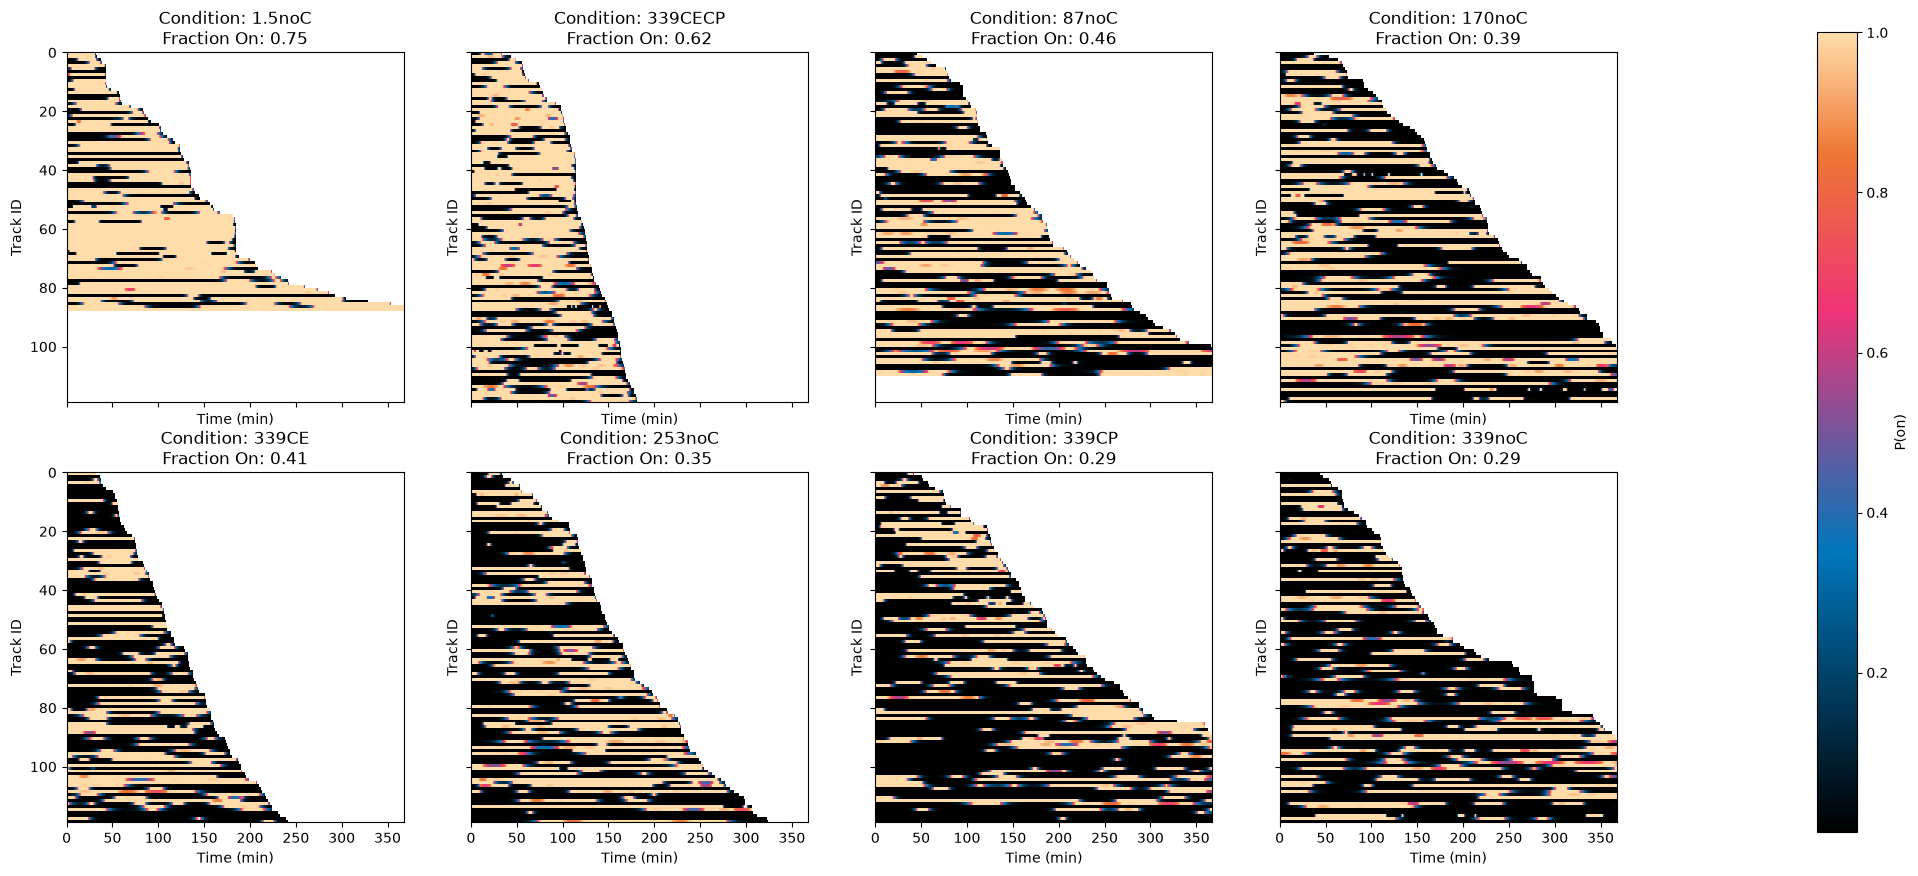

In [9]:


pt_heatmap_cmap = LinearSegmentedColormap.from_list(
    "PT_Inferno",
    [
        (0.00, "#000000"),
        (0.35, colors_pt["blue"]),
        (0.65, colors_pt["magenta"]),
        (0.85, colors_pt["orange"]),
        (1.00, "#FFDDAA"),
    ],
)

frac_on = [np.nanmean(mapval) for mapval in pons]
fig,ax = plt.subplots(2,4,figsize=(20,10),sharex=True,sharey=True)
ms2_min,ms2_max = -10,200
nbins = 50
for i,mapval in enumerate(pons):
    lensort = np.argsort(np.sum(~np.isnan(mapval), axis=1))
    im = ax.flatten()[i].imshow(mapval[lensort], cmap=pt_heatmap_cmap,aspect="auto",interpolation="none",extent=[0, len(mapval[0])*0.5,len(mapval), 0])
    ax.flatten()[i].set(title=f"Condition: {condition_labels[i]}\nFraction On: {frac_on[i]:.2f}")
    ax.flatten()[i].set(xlabel="Time (min)", ylabel="Track ID")
# make outside axis for colorbar 
cbar_ax = fig.add_axes([1.0, 0.1, 0.02, 0.8])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("P(on)")

fig.savefig("figures/Supplement_figures/Inference_no_drive/pon_maps.pdf", bbox_inches="tight")

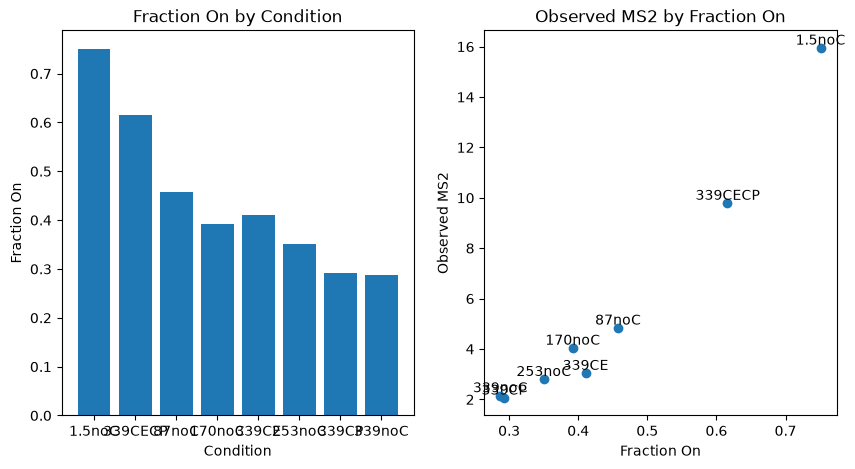

In [10]:
frac_on = [np.nanmean(mapval) for mapval in pons]
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].bar(condition_labels, frac_on)
ax[0].set(title="Fraction On by Condition", xlabel="Condition", ylabel="Fraction On")
ax[1].plot(frac_on,avg_observed_MS2,"o")
ax[1].set(title="Observed MS2 by Fraction On", xlabel="Fraction On", ylabel="Observed MS2")
# add condition labels to the observed MS2 plot
for i, (label, frac) in enumerate(zip(condition_labels, frac_on)):
    ax[1].text(frac_on[i], avg_observed_MS2[i], label, ha="center", va="bottom")

fig.savefig("figures/Supplement_figures/Inference_no_drive/fraction_on_vs_observed_MS2.pdf")